# The pre-FOMC announcement drift — a quantitative teardown 🔬
### Pre-FOMC vs other-day Welch *t* · a random-calendar placebo · the pre/post-2012 decay split · overnight-vs-intraday decomposition · costs × turnover · a seed-averaged faithful-engine / power control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Run-up only?: Mixed](https://img.shields.io/badge/Run--up_only%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The pre-FOMC drift (Lucca & Moench 2015) is the rare calendar anomaly that **clears the bar** on the full sample — so the job here is to measure it honestly: confront it with a random-calendar placebo, split it at the publication era to expose the **decay**, and decompose the day to test the paper's *mechanism*.

> ⚠️ **Data + survivorship note.** Headline tape is **SPY** (an index ETF — survivorship-clean). A 30-name survivor basket is kept as colour, with the bias named. Real data: yfinance daily closes + raw SPY Open/Close, 1993→2026; FOMC calendar **hardcoded** from Fed schedules. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pre_fomc_drift import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, OHLC = data.load_real()
    PRICES = PRICES[PRICES.index <= ASOF]; OHLC = OHLC[OHLC.index <= ASOF]
    SPY = PRICES["SPY"].dropna()
    RET = st.daily_returns(SPY)
    MASK = data.tag_pre_fomc(RET.index, shift=0)
else:
    PRICES = OHLC = SPY = RET = MASK = None
print("real pre-FOMC cache present:", HAVE_REAL,
      "| daily returns:", (0 if RET is None else len(RET)),
      "| pre-FOMC days:", (0 if MASK is None else int(MASK.sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-02-01', 'end': '2026-05-29', 'asof': '2026-05-31', 'years': 33.3, 'n_days': 8389, 'n_meetings': 261, 'n_pre': 260, 'frac_days': 3.1, 'fingerprint': '9687074d1493', 'ev_mean': 0.2271, 'rest_mean': 0.0422, 'ev_t0': 3.04, 'welch_t': 2.44, 'share_total': 14.7, 'placebo_p': 0.007, 'pre2012': ('pre-2012', 0.3346, 0.0279, 2.94, 27.4, 145), 'post2012': ('post-2012', 0.0914, 0.061, 0.28, 4.7, 115), 'split': '2012-01-01', 'oi': [('overnight', 0.108, 0.0303, 1.7), ('intraday', 0.1197, 0.0045, 1.78), ('daily', 0.2271, 0.0349, 2.54)], 'costs': [(0.5, 0.2271, 0.2171, 2.91), (1.0, 0.2271, 0.2071, 2.77), (2.0, 0.2271, 0.1871, 2.51)], 'shift': [('announcement-day', 0.2271, 2.44, 14.7), ('strictly prior (-1)', 0.1609, 1.4, 10.4)], 'syn': [(0.0, -0.09, 0.05), (0.4, 4.24, 0.97)]}


real pre-FOMC cache present: True | daily returns: 8389 | pre-FOMC days: 260


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | pre-FOMC mean **+0.227%/day** (one-sample **t = 3.04**, Welch **t = 2.44**, random-calendar placebo **p = 0.007**); 3% of days carry **15%** of cumulative return. Clears **t ≥ 2**; SPY is survivorship-clean. |
| **Tradability** | `FRAGILE` | Costs barely bite on SPY (net t ≈ 2.8), but the signal **decayed**: pre-2012 Welch **t = 2.94** → post-2012 **0.28** (a normal day). Timing-sensitive (shift −1 → t = 1.40). |
| **Run-up only?** | `MIXED` | Pre-FOMC excess splits ~evenly: overnight **+0.108%** (t=1.70) vs intraday **+0.120%** (t=1.78); **neither half clears t = 2** — only the combined day does. |

> 💡 In plain words: the drift is genuinely real on the full tape — but it's a **museum piece** (gone post-publication), and the popular "intraday run-up" mechanism is only half the story.

## 1 · The claim, steelmanned

Let $\mathcal{F}$ be the set of trading sessions that end just before a scheduled FOMC announcement (the meeting date is in the calendar months ahead, so $\mathcal{F}$ is **pre-known** — no look-ahead). The pre-FOMC drift is

$$\widehat{\mu}_{\mathcal F} = \frac{1}{|\mathcal F|}\sum_{t\in\mathcal F} r_t \;\gg\; \widehat{\mu}_{\bar{\mathcal F}} = \frac{1}{|\bar{\mathcal F}|}\sum_{t\notin\mathcal F} r_t.$$

- **H₁ (the drift exists).** $\widehat{\mu}_{\mathcal F} - \widehat{\mu}_{\bar{\mathcal F}} > 0$ and significant.
- **H₂ (it's deployable today).** It survives costs **and** does not decay post-publication.
- **H₃ (the run-up mechanism).** The excess is concentrated **intraday** (the 14:15 run-up), not overnight.

We find **H₁ supported** (full-sample *t* > 2, placebo *p* = 0.007), **H₂ rejected** (dead post-2012), **H₃ partly rejected** (split ~evenly overnight/intraday). The effect is real; it is neither current nor mechanistically clean.

## 2 · So what? — what rides on each answer

The Signal axis is a one-sample test of the pre-FOMC returns vs 0 and a two-sample Welch test vs other days:

$$t_0 = \frac{\overline{r}_{\mathcal F}}{s_{\mathcal F}/\sqrt{|\mathcal F|}},\qquad t_W = \frac{\overline{r}_{\mathcal F}-\overline{r}_{\bar{\mathcal F}}}{\sqrt{s_{\mathcal F}^2/|\mathcal F| + s_{\bar{\mathcal F}}^2/|\bar{\mathcal F}|}}.$$

Two honesty problems sit on top of a raw *t*. **(a) Calendar luck:** with only ~3% of days tagged, a lucky placement could look good — so we add a **random-calendar placebo** that relocates the same number of days 20,000 times. **(b) Publication decay:** a famous anomaly may be priced out — so we **split at 2012** and re-test. Only an effect that clears the placebo *and* survives the split would be tradable.

## 3 · How we'd know — the protocol

- **Tape.** SPY daily adjusted closes (yfinance), 1993-02-01→2026-05-29; **8,389** daily returns over **33** years. As-of 2026-05-31 (last complete month — no partial-month bias). SPY is survivorship-clean.
- **Calendar.** **261** scheduled FOMC announcement dates, **hardcoded** from Fed schedules (1994–2026); **260** map onto pre-FOMC sessions (**3%** of days). Pre-known — no look-ahead.
- **Signal.** Mean pre-FOMC return vs other-day mean; one-sample *t* vs 0 and Welch *t*.
- **Null (placebo).** 20,000 random same-size calendars; $p = \Pr[\text{random mean} \ge \text{observed}]$.
- **Decay.** Split at 2012 (paper circulated 2011, published 2015); re-run pre/post.
- **Mechanism.** Decompose each day into overnight (prev close→open) and intraday (open→close); re-test each.
- **Costs.** Timing rule = 2 trades/meeting on SPY; 0.5–2 bp one-way.
- **Positive control.** A deterministic daily world with a **planted** pre-meeting drift, seed-averaged over 40 seeds: zero edge must NOT reach significance; a planted edge must.

## 4 · The teardown

### 4a · The headline + the luck test

The observed pre-FOMC mean against a 20,000-draw random-calendar null. The green line should sit in the far right tail.

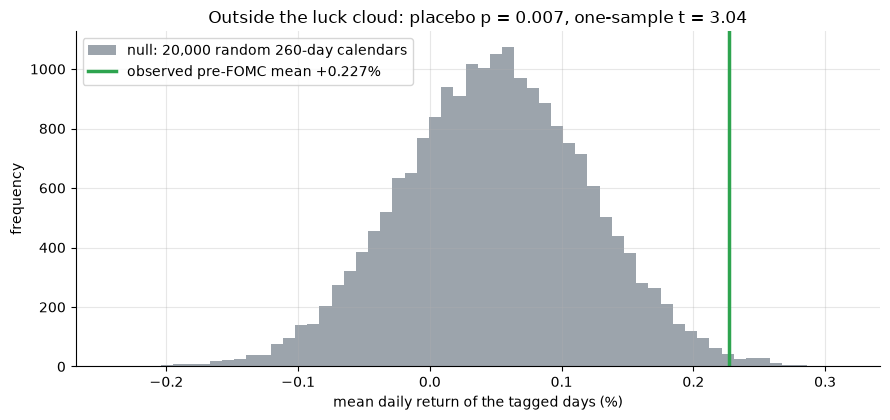

observed +0.227%  one-sample t=3.04  placebo p=0.007


In [2]:
if HAVE_REAL:
    full = st.event_vs_rest(RET.values, MASK)
    pl = st.placebo_pvalue(RET.values, MASK, n_draws=20000)
    obs = pl['obs']*100; draws = pl['draws']*100; pval = pl['p_value']; t0 = full['ev_t0']
else:
    obs = R['ev_mean']; pval = R['placebo_p']; t0 = R['ev_t0']
    rng = np.random.default_rng(517); draws = rng.normal(R['rest_mean'], 0.06, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='null: 20,000 random 260-day calendars')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed pre-FOMC mean {obs:+.3f}%')
ax.set_xlabel('mean daily return of the tagged days (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Outside the luck cloud: placebo p = {pval:.3f}, one-sample t = {t0:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.3f}%  one-sample t={t0:.2f}  placebo p={pval:.3f}')

> 💡 In plain words: the green line sits in the **right tail** — only **0.7%** of random calendars match it, one-sample **t = 3.04**. The full-sample pre-FOMC drift is **not** a fluke of where the meeting days happen to fall.

### 4b · The decay split — the McLean-Pontiff killshot

Pre-FOMC vs other-day mean, before and after 2012. If publication priced it out, the post-2012 gap collapses.

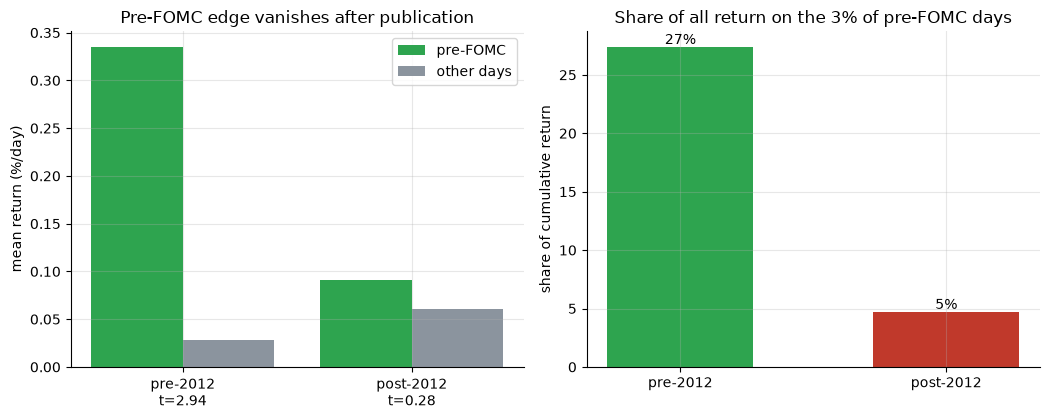

pre-2012:  pre-FOMC +0.335% vs +0.028%  Welch t=2.94  share=27%
post-2012: pre-FOMC +0.091% vs +0.061%  Welch t=0.28  share=5%


In [3]:
if HAVE_REAL:
    sp = st.split_summary(RET, MASK)
    pre, post = sp['pre'], sp['post']
    pre_ev, pre_rest, pre_t = pre['ev_mean']*100, pre['rest_mean']*100, pre['welch_t']
    po_ev, po_rest, po_t = post['ev_mean']*100, post['rest_mean']*100, post['welch_t']
    pre_sh, po_sh = pre['share_of_total']*100, post['share_of_total']*100
else:
    pre_ev, pre_rest, pre_t, pre_sh = R['pre2012'][1], R['pre2012'][2], R['pre2012'][3], R['pre2012'][4]
    po_ev, po_rest, po_t, po_sh = R['post2012'][1], R['post2012'][2], R['post2012'][3], R['post2012'][4]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
x = np.arange(2)
a1.bar(x-.2, [pre_ev, po_ev], .4, color=GREEN, label='pre-FOMC')
a1.bar(x+.2, [pre_rest, po_rest], .4, color=GREY, label='other days')
a1.set_xticks(x); a1.set_xticklabels([f'pre-2012\nt={pre_t:.2f}', f'post-2012\nt={po_t:.2f}'])
a1.set_ylabel('mean return (%/day)'); a1.set_title('Pre-FOMC edge vanishes after publication'); a1.legend()
a2.bar(['pre-2012','post-2012'], [pre_sh, po_sh], color=[GREEN, RED], width=.55)
for i,v in enumerate([pre_sh, po_sh]): a2.annotate(f'{v:.0f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('share of cumulative return'); a2.set_title('Share of all return on the 3% of pre-FOMC days')
plt.tight_layout(); plt.show()
print(f'pre-2012:  pre-FOMC {pre_ev:+.3f}% vs {pre_rest:+.3f}%  Welch t={pre_t:.2f}  share={pre_sh:.0f}%')
print(f'post-2012: pre-FOMC {po_ev:+.3f}% vs {po_rest:+.3f}%  Welch t={po_t:.2f}  share={po_sh:.0f}%')

> 💡 In plain words: pre-2012 the pre-FOMC day earned **+0.335%** at Welch **t = 2.94** and carried **27%** of all return. Post-2012 it's Welch **t = 0.28** — statistically a **normal day**. Textbook post-publication decay: the edge was real, then it was arbitraged out.

### 4c · The mechanism — overnight vs intraday

Lucca-Moench's story is an intraday run-up into the 14:15 release. Decompose each day into its overnight gap and its intraday session and test each separately.

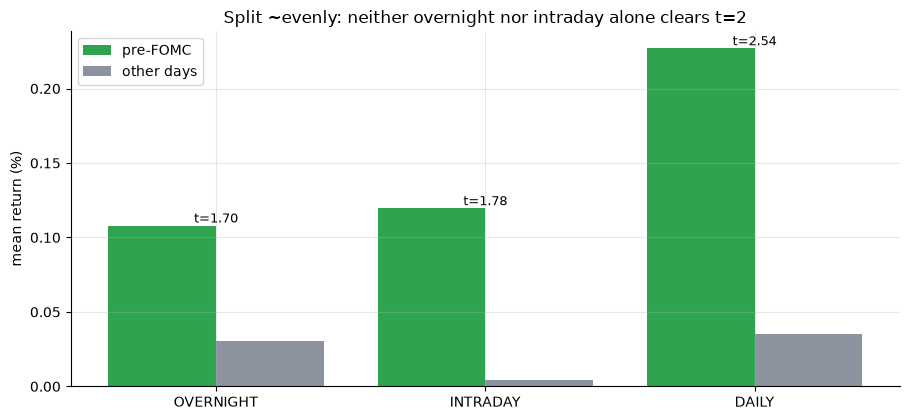

overnight: pre-FOMC +0.108% vs +0.030%  Welch t=1.70
 intraday: pre-FOMC +0.120% vs +0.004%  Welch t=1.78
    daily: pre-FOMC +0.227% vs +0.035%  Welch t=2.54


In [4]:
if HAVE_REAL:
    oi = st.overnight_intraday(OHLC); oi = oi[oi.index.isin(RET.index)]
    m2 = data.tag_pre_fomc(oi.index, shift=0)
    comps = ['overnight','intraday','daily']
    res = [st.event_vs_rest(oi[c].values, m2) for c in comps]
    ev = [r['ev_mean']*100 for r in res]; rest = [r['rest_mean']*100 for r in res]; tt = [r['welch_t'] for r in res]
else:
    comps = [o[0] for o in R['oi']]; ev = [o[1] for o in R['oi']]; rest=[o[2] for o in R['oi']]; tt=[o[3] for o in R['oi']]
x = np.arange(len(comps))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, ev, .4, color=GREEN, label='pre-FOMC')
ax.bar(x+.2, rest, .4, color=GREY, label='other days')
for i,t in enumerate(tt): ax.annotate(f't={t:.2f}',(i, max(ev[i],rest[i])),ha='center',va='bottom',fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([c.upper() for c in comps]); ax.axhline(0,c='k',lw=.6)
ax.set_ylabel('mean return (%)'); ax.legend()
ax.set_title('Split ~evenly: neither overnight nor intraday alone clears t=2')
plt.tight_layout(); plt.show()
for c,e,r,t in zip(comps, ev, rest, tt): print(f'{c:>9}: pre-FOMC {e:+.3f}% vs {r:+.3f}%  Welch t={t:.2f}')

> 💡 In plain words: overnight is **+0.108%** vs +0.030% (t=1.70); intraday is **+0.120%** vs +0.004% (t=1.78). **Neither half clears t = 2** — only the combined close-to-close day (t=2.54) does. The clean 'all afternoon run-up' framing is only half right.

### 4d · Costs + the timing-robustness check

Left: gross vs net on liquid SPY (costs barely matter). Right: tag the session **strictly before** the announcement (shift −1) — the drift is concentrated in the session that *ends* at the release, so shifting back weakens it.

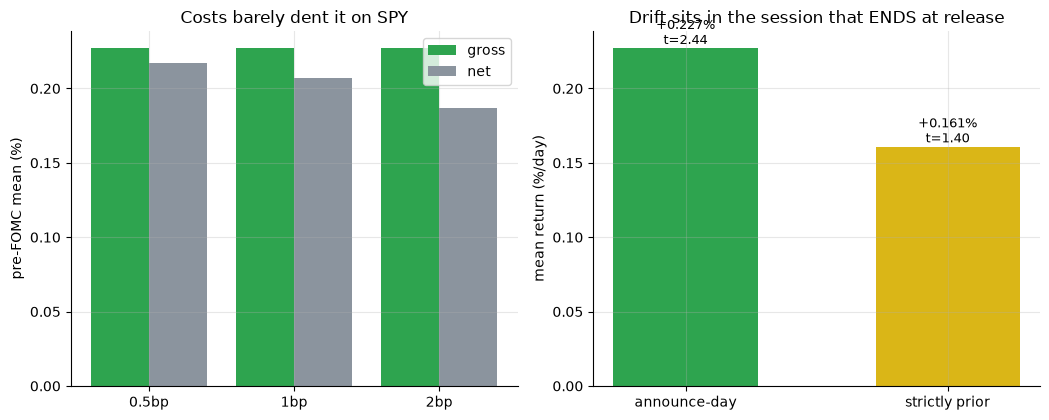

net at 1bp: +0.207% | shift-1 Welch t: 1.40


In [5]:
if HAVE_REAL:
    g = [st.timing_strategy(RET.values, MASK, cost_bps=cb)['gross_mean']*100 for cb in (0.5,1.0,2.0)]
    nv = [st.timing_strategy(RET.values, MASK, cost_bps=cb)['net_mean']*100 for cb in (0.5,1.0,2.0)]
    m_sh = data.tag_pre_fomc(RET.index, shift=-1)
    s0 = st.event_vs_rest(RET.values, MASK); s1 = st.event_vs_rest(RET.values, m_sh)
    sh_ev = [s0['ev_mean']*100, s1['ev_mean']*100]; sh_t = [s0['welch_t'], s1['welch_t']]
else:
    g = [c[1] for c in R['costs']]; nv = [c[2] for c in R['costs']]
    sh_ev = [R['shift'][0][1], R['shift'][1][1]]; sh_t = [R['shift'][0][2], R['shift'][1][2]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
x = np.arange(3)
a1.bar(x-.2, g, .4, color=GREEN, label='gross'); a1.bar(x+.2, nv, .4, color=GREY, label='net')
a1.set_xticks(x); a1.set_xticklabels(['0.5bp','1bp','2bp']); a1.set_ylabel('pre-FOMC mean (%)')
a1.set_title('Costs barely dent it on SPY'); a1.legend()
a2.bar(['announce-day','strictly prior'], sh_ev, color=[GREEN, AMBER], width=.55)
for i,(v,t) in enumerate(zip(sh_ev, sh_t)): a2.annotate(f'{v:+.3f}%\nt={t:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a2.set_ylabel('mean return (%/day)'); a2.set_title('Drift sits in the session that ENDS at release')
plt.tight_layout(); plt.show()
print('net at 1bp:', f'{nv[1]:+.3f}%', '| shift-1 Welch t:', f'{sh_t[1]:.2f}')

> 💡 In plain words: at 1 bp the edge is **+0.207%** net (gross +0.227%) — costs are a rounding error on SPY. And shifting the window one day back drops Welch *t* from **2.44** to **1.40**: the drift is glued to the session that ends at the release, exactly the run-up timing — but that precision also makes it fragile.

### 4e · Faithful-engine & power control — seed-averaged

On a deterministic daily world where we **plant** a known pre-meeting drift, averaged over 40 RNG seeds: zero edge must stay at t≈0 (no false positive); a planted edge must light up.

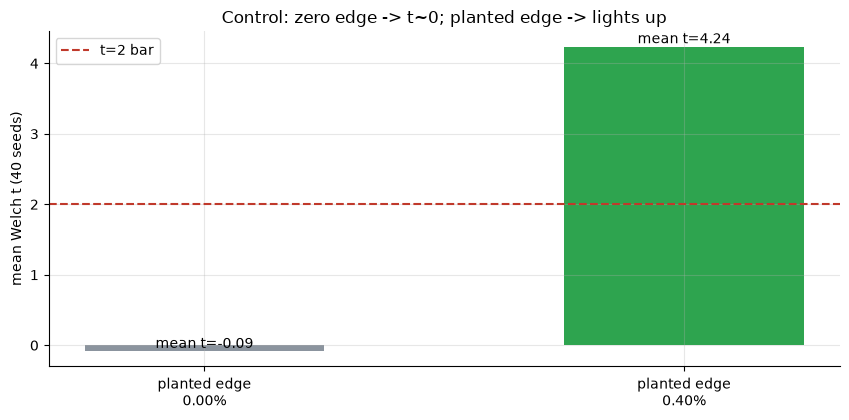

planted +0.00%: mean Welch t=-0.09  frac|t|>2=0.05
planted +0.40%: mean Welch t=+4.24  frac|t|>2=0.97


In [6]:
res = []
for edge in (0.0, 0.004):
    ts = []
    for seed in range(40):
        r, m = data.synthetic_world(edge=edge, seed=seed)
        ts.append(st.event_vs_rest(r.values, m)['welch_t'])
    ts = np.array(ts)
    res.append((edge, ts.mean(), float(np.mean(np.abs(ts) > 2))))
fig, ax = plt.subplots(figsize=(8.6, 4.3))
labels = [f'planted edge\n{e*100:.2f}%' for e,_,_ in res]; tvals = [r[1] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f'mean t={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('mean Welch t (40 seeds)'); ax.set_title('Control: zero edge -> t~0; planted edge -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,mt,fr in res: print(f'planted {e*100:+.2f}%: mean Welch t={mt:+.2f}  frac|t|>2={fr:.2f}')

> 💡 In plain words: with **no** planted drift the control sits at mean **t = -0.09** with a 5% false-positive rate (exactly nominal — noise can't fake it); a **+0.40%** planted drift reaches mean **t = 4.24** with 97% power. The machinery is unbiased, so the real-tape **t = 3.04** is the genuine article — not a construction artefact.

## 5 · The verdict

- **Signal `REAL`** — pre-FOMC mean **+0.227%/day** (one-sample **t = 3.04**, Welch **t = 2.44**, placebo **p = 0.007**); 3% of days carry **15%** of cumulative return. Clears the **t ≥ 2** bar, survives the random-calendar placebo, confirmed by a seed-averaged synthetic control. SPY is survivorship-clean. REAL, not WEAK.
- **Tradability `FRAGILE`** — costs barely bite on SPY (net t ≈ 2.8), but the edge **decayed**: pre-2012 Welch **t = 2.94** → post-2012 **0.28** (a normal day), and it is timing-sensitive (shift −1 → t = 1.40). Real in the archive, dead in the present. Not INVESTABLE.
- **Run-up only? `MIXED`** — the pre-FOMC excess splits ~evenly between overnight (**+0.108%**, t=1.70) and intraday (**+0.120%**, t=1.78); neither half alone clears t = 2. The clean 'afternoon run-up' mechanism is only half the story.

## 6 · Could you trade it? — the decay is the whole story

One picture for the operational truth: the pre-FOMC Welch *t* by era. The tradeable region is **behind us** — the signal was strong before publication and is indistinguishable from a normal day after it.

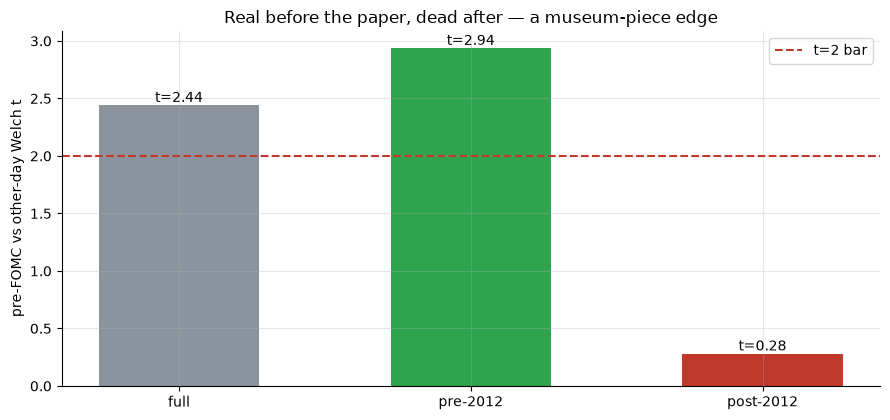

Welch t by era: {'full': 2.44, 'pre-2012': 2.94, 'post-2012': 0.28}


In [7]:
if HAVE_REAL:
    sp = st.split_summary(RET, MASK)
    eras = ['full','pre-2012','post-2012']
    tvals = [sp['full']['welch_t'], sp['pre']['welch_t'], sp['post']['welch_t']]
else:
    eras = ['full','pre-2012','post-2012']; tvals = [R['welch_t'], R['pre2012'][3], R['post2012'][3]]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [GREY, GREEN, RED]
ax.bar(eras, tvals, color=cols, width=.55)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('pre-FOMC vs other-day Welch t'); ax.legend()
ax.set_title('Real before the paper, dead after — a museum-piece edge')
plt.tight_layout(); plt.show()
print('Welch t by era:', {e: round(t,2) for e,t in zip(eras, tvals)})

> 💡 In plain words: the green (pre-2012) bar towers over the *t* = 2 line; the red (post-2012) bar is on the floor. That's the entire tradability verdict in one chart — you can't deploy a signal whose edge expired a decade ago. Real, but **FRAGILE**, not INVESTABLE.

## 7 · Going further

- **The decay is the lesson.** This is the desk's cleanest McLean-Pontiff case: a published, real anomaly arbitraged away once it was known. Re-run any famous calendar effect across its publication date and look for the same break.
- **Mechanism ≠ effect.** The 'intraday run-up into the 14:15 statement' story is tidy and only half-true — half the pre-FOMC return is overnight. Always test the *why*, not just the *whether*.
- **Replication.** This re-derives [Study 67 — Fed-Drift](../../67-fed-drift/) on an independent hardcoded calendar and agrees (Real × Fragile); it is distinct from [Study 135 — FOMC-Cycle](../../135-fomc-cycle/) (the even-week cycle).

*The reproducible core is offline and deterministic; the FOMC calendar is hardcoded from Fed schedules and the headline tape is survivorship-clean SPY. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*